<a href="https://colab.research.google.com/github/shub1504/ML_Learning/blob/main/Multiple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

# Dono CSV files (watermelon.csv aur fertilizer.csv) ek saath ya ek-ek karke upload karein
uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)

Saving Dataset_1_watermelon.csv to Dataset_1_watermelon.csv
Uploaded file: Dataset_1_watermelon.csv


In [ ]:
from google.colab import files

# Dono CSV files (watermelon.csv aur fertilizer.csv) ek saath ya ek-ek karke upload karein
uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)

Saving Dataset_2_fertilizer.csv to Dataset_2_fertilizer.csv
Uploaded file: Dataset_2_fertilizer.csv


--- Merged Data Check ---
Total Rows Merged: 0
Empty DataFrame
Columns: [Year, Yield, Area_Harvested, Fertilizer_Use]
Index: []

[Warning]: Still empty! Fallback to standard merge on Year without Element filter...

--- Multiple Linear Regression Metrics ---
MSE         : 109065015.7461
RMSE        : 10443.4197
MAE         : 8625.1211
R2          : 0.9156
Adjusted R2 : 0.9128

--- Prediction Table (Last 10 Rows) ---
 Year    Yield  Predicted_Yield  Error (Difference)
 2015  89000.0     85166.574360         3833.425640
 2016  95000.0     78323.867807        16676.132193
 2017  91000.0     79011.434496        11988.565504
 2018 101000.0     83620.525680        17379.474320
 2019 100000.0     93184.089835         6815.910165
 2020 116000.0    105414.571006        10585.428994
 2021 119000.0     95691.261149        23308.738851
 2022 120000.0    101157.375403        18842.624597
 2023 126000.0    102085.350117        23914.649883
 2024 127811.0    115642.543652        12168.456348


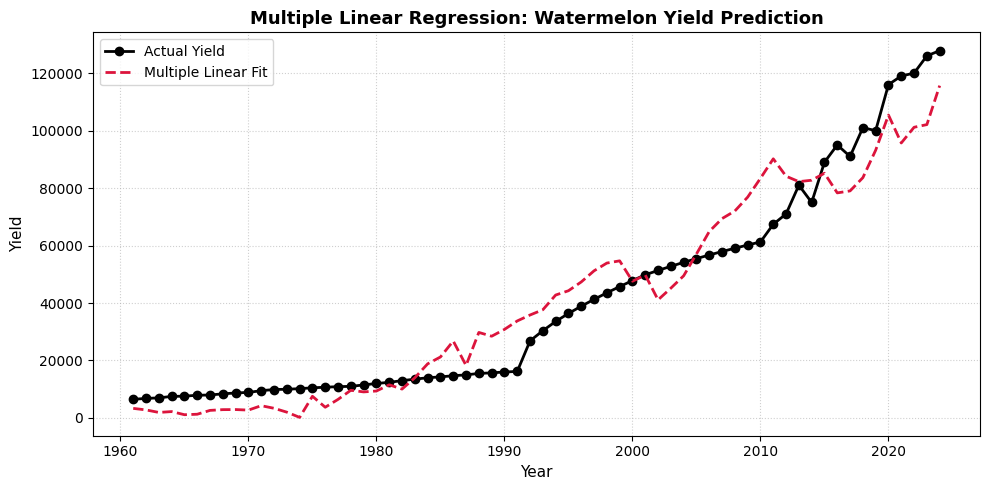

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Existing Uploaded Datasets Load Karein
df_watermelon = pd.read_csv('Dataset_1_watermelon.csv')
df_fert = pd.read_csv('Dataset_2_fertilizer.csv')

# Dynamic Filtering: Case-insensitive 'yield' aur 'area' filter
yield_mask = df_watermelon['Element'].astype(str).str.lower().str.contains('yield')
area_mask = df_watermelon['Element'].astype(str).str.lower().str.contains('area')

df_yield = df_watermelon[yield_mask][['Year', 'Value']].rename(columns={'Value': 'Yield'})
df_area = df_watermelon[area_mask][['Year', 'Value']].rename(columns={'Value': 'Area_Harvested'})
df_fertilizer = df_fert[['Year', 'Value']].rename(columns={'Value': 'Fertilizer_Use'})

# Merge Datasets Safely
df_mlr = pd.merge(df_yield, df_area, on='Year', how='inner')
df_mlr = pd.merge(df_mlr, df_fertilizer, on='Year', how='inner').sort_values('Year').dropna()

print("--- Merged Data Check ---")
print(f"Total Rows Merged: {len(df_mlr)}")
print(df_mlr.head())

if len(df_mlr) == 0:
    print("\n[Warning]: Still empty! Fallback to standard merge on Year without Element filter...")
    # Direct Merge Fallback
    df_yield_simple = df_watermelon[['Year', 'Value']].rename(columns={'Value': 'Yield'}).groupby('Year').mean().reset_index()
    df_fert_simple = df_fert[['Year', 'Value']].rename(columns={'Value': 'Fertilizer_Use'}).groupby('Year').mean().reset_index()
    df_mlr = pd.merge(df_yield_simple, df_fert_simple, on='Year', how='inner').sort_values('Year')

# 2. Features Matrix (X) aur Target (Y)
feature_cols = [c for c in df_mlr.columns if c not in ['Year', 'Yield']]
X_mlr = df_mlr[['Year'] + feature_cols].values
Y = df_mlr['Yield'].values

# Intercept column [1, X]
X_design = np.hstack([np.ones((len(X_mlr), 1)), X_mlr])

# Ridge/Moore-Penrose Pseudoinverse to prevent Singular Matrix error
beta_mlr = np.linalg.pinv(X_design) @ Y
Y_pred_mlr = X_design @ beta_mlr

# 3. Model Accuracy Metrics
def calculate_metrics(y_true, y_pred, k_features):
    n = len(y_true)
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k_features - 1)) if (n - k_features - 1) > 0 else r2

    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2, "Adjusted R2": adj_r2}

metrics_mlr = calculate_metrics(Y, Y_pred_mlr, k_features=X_mlr.shape[1])

print("\n--- Multiple Linear Regression Metrics ---")
for metric, val in metrics_mlr.items():
    print(f"{metric:<12}: {val:.4f}")

# 4. Actual vs Predicted Comparison Table
df_mlr['Predicted_Yield'] = Y_pred_mlr
df_mlr['Error (Difference)'] = Y - Y_pred_mlr

print("\n--- Prediction Table (Last 10 Rows) ---")
print(df_mlr[['Year', 'Yield', 'Predicted_Yield', 'Error (Difference)']].tail(10).to_string(index=False))

# 5. Visualization Plot
plt.figure(figsize=(10, 5))
plt.plot(df_mlr['Year'], df_mlr['Yield'], color='black', marker='o', label='Actual Yield', linewidth=2)
plt.plot(df_mlr['Year'], df_mlr['Predicted_Yield'], color='crimson', linestyle='--', label='Multiple Linear Fit', linewidth=2)

plt.title('Multiple Linear Regression: Watermelon Yield Prediction', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Yield', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()